# ID_00

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"

ids = os.listdir(base_path)
print("Available IDs:", ids)

for id_name in ids:
    id_path = os.path.join(base_path, id_name)
    if os.path.isdir(id_path):
        print(f"\n{id_name} contains:")
        print(os.listdir(id_path))

Available IDs: ['id_00', 'id_02', 'id_04', 'id_06']

id_00 contains:
['abnormal', 'normal']

id_02 contains:
['abnormal', 'normal']

id_04 contains:
['abnormal', 'normal']

id_06 contains:
['abnormal', 'normal']


In [ ]:
import glob

normal_files = []
abnormal_files = []

for id_name in os.listdir(base_path):
    id_path = os.path.join(base_path, id_name)

    normal_path = os.path.join(id_path, "normal")
    abnormal_path = os.path.join(id_path, "abnormal")

    normal_files += glob.glob(normal_path + "/*.wav")
    abnormal_files += glob.glob(abnormal_path + "/*.wav")

print("Total normal files:", len(normal_files))
print("Total abnormal files:", len(abnormal_files))

Total normal files: 4075
Total abnormal files: 1475


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [ ]:
def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]

    return mel

In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_00"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1011
Abnormal files: 407


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel

In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

Normal AE train: 707
Normal RF: 152
Normal test: 152
Abnormal RF: 284
Abnormal test: 123


In [ ]:
X_train = []

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2DTranspose(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2DTranspose(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2DTranspose(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2DTranspose(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)


In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data

X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)

In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)


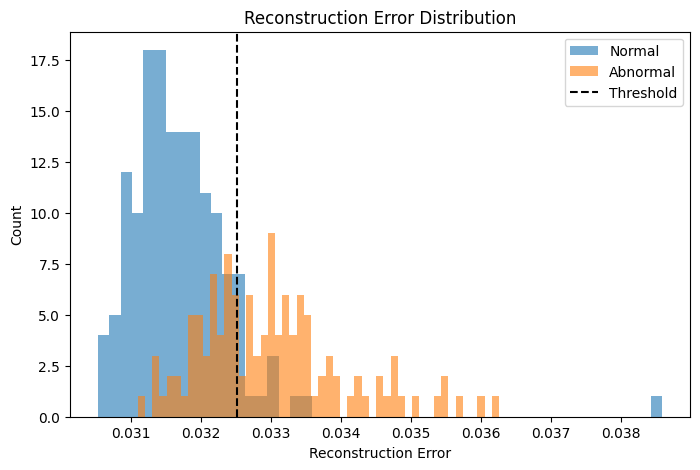

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')
threshold = np.mean(error_normal) + 1*np.std(error_normal)

plt.axvline(threshold, color='black', linestyle='--', label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()


In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)


Threshold: 0.034011085


In [ ]:
# Save model
model.save("model_id_00.keras")

# Save normalization parameters
np.save("train_min_id_00.npy", train_min)
np.save("train_max_id_00.npy", train_max)

# Save threshold
# np.save("threshold_id_00.npy", threshold)

# print("All deployment files saved for id_00")

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_00.keras")

train_min = np.load("train_min_id_00.npy").item()
train_max = np.load("train_max_id_00.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_00_features.csv",index=False)

print("id_00_features.csv created")

id_00_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_00_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_00_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

RF CV AUC: 0.8784 ± 0.0206


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

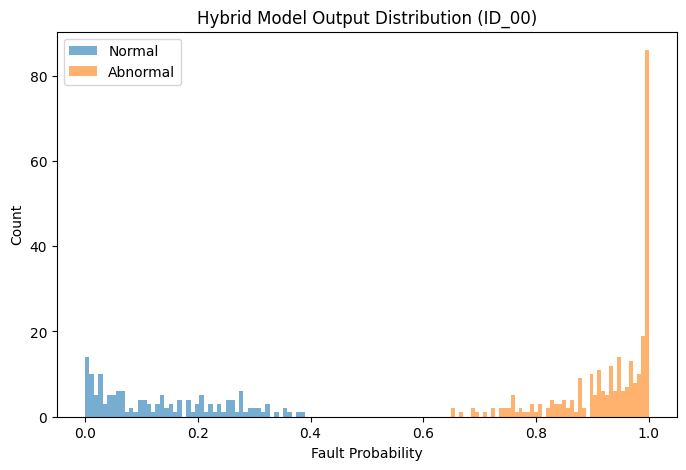

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
# Use the X data that the rf_model was trained on, along with its labels y
prob = rf_model.predict_proba(X)[:,1]

# split by label
normal_prob = prob[y == 0]
abnormal_prob = prob[y == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_00)")

plt.legend()
plt.show()

        HELD-OUT TEST SET METRICS
  AUC Score       : 0.9039
  pAUC (FPR≤0.1)  : 0.7752
  pAUC Normalized : 7.7521
  Accuracy        : 0.8000
  Precision       : 0.7267
  Recall          : 0.8862
  F1 Score        : 0.7985

Classification Report:
              precision    recall  f1-score   support

      Normal       0.89      0.73      0.80       152
    Abnormal       0.73      0.89      0.80       123

    accuracy                           0.80       275
   macro avg       0.81      0.81      0.80       275
weighted avg       0.82      0.80      0.80       275



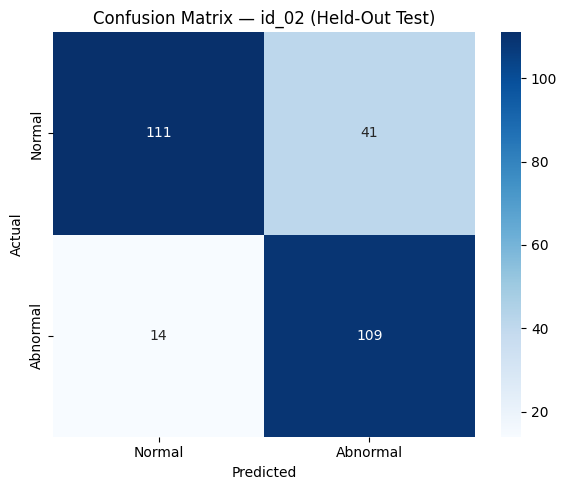

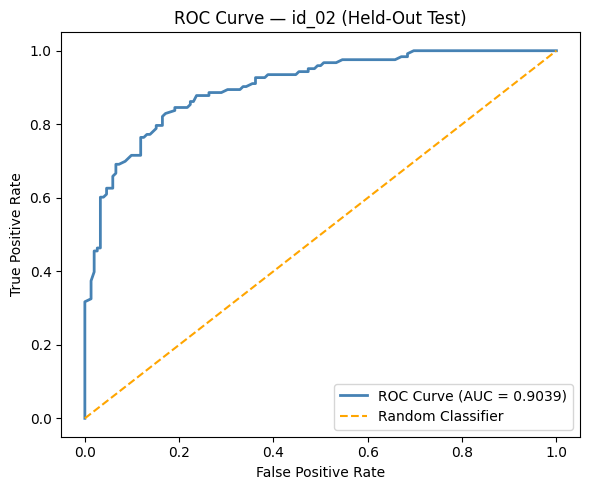


RF Cross-Validation AUC (training set): 0.8784 ± 0.0206
RF Held-Out Test AUC:                    0.9039


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────
# STEP 1: Extract features from HELD-OUT test set
# ─────────────────────────────────────────

test_results = []

for file in normal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["normal", error, centroid, bandwidth, energy, dom])

for file in abnormal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["abnormal", error, centroid, bandwidth, energy, dom])

df_test = pd.DataFrame(
    test_results,
    columns=["condition", "reconstruction_error",
             "centroid", "bandwidth", "energy", "dominant_freq"]
)

# ─────────────────────────────────────────
# STEP 2: Prepare test features and labels
# ─────────────────────────────────────────

X_final = df_test[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]
y_final = df_test["condition"].map({"normal": 0, "abnormal": 1})

prob  = rf_model.predict_proba(X_final)[:, 1]
y_pred = rf_model.predict(X_final)

# ─────────────────────────────────────────
# STEP 3: Print all metrics including pAUC
# ─────────────────────────────────────────

auc = roc_auc_score(y_final, prob)

# pAUC restricted to FPR <= 0.1 (official MIMII metric)
pauc = roc_auc_score(y_final, prob, max_fpr=0.1)

# pAUC normalized to [0,1] range by dividing by the FPR limit
pauc_normalized = pauc / 0.1

print("=" * 45)
print("        HELD-OUT TEST SET METRICS")
print("=" * 45)
print(f"  AUC Score       : {auc:.4f}")
print(f"  pAUC (FPR≤0.1)  : {pauc:.4f}")
print(f"  pAUC Normalized : {pauc_normalized:.4f}")
print(f"  Accuracy        : {accuracy_score(y_final, y_pred):.4f}")
print(f"  Precision       : {precision_score(y_final, y_pred):.4f}")
print(f"  Recall          : {recall_score(y_final, y_pred):.4f}")
print(f"  F1 Score        : {f1_score(y_final, y_pred):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_final, y_pred, target_names=["Normal", "Abnormal"]))

# ─────────────────────────────────────────
# STEP 4: Confusion Matrix
# ─────────────────────────────────────────

cm = confusion_matrix(y_final, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — id_02 (Held-Out Test)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 5: ROC Curve
# ─────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_final, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — id_02 (Held-Out Test)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 6: CV AUC on RF training set
# ─────────────────────────────────────────

print(f"\nRF Cross-Validation AUC (training set): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"RF Held-Out Test AUC:                    {auc:.4f}")

#ID_02


In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_02"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1016
Abnormal files: 359


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel


In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

Normal AE train: 711
Normal RF: 152
Normal test: 153
Abnormal RF: 251
Abnormal test: 108


In [ ]:
X_train = []

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (711, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2DTranspose(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2DTranspose(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2DTranspose(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2DTranspose(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - loss: 0.0226 - val_loss: 0.0146
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0127 - val_loss: 0.0116
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0111 - val_loss: 0.0106
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0095 - val_loss: 0.0091
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0076 - val_loss: 0.0074
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0071 - val_loss: 0.0069
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data

X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)


In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 517ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)


AUC: 0.9816630355846043


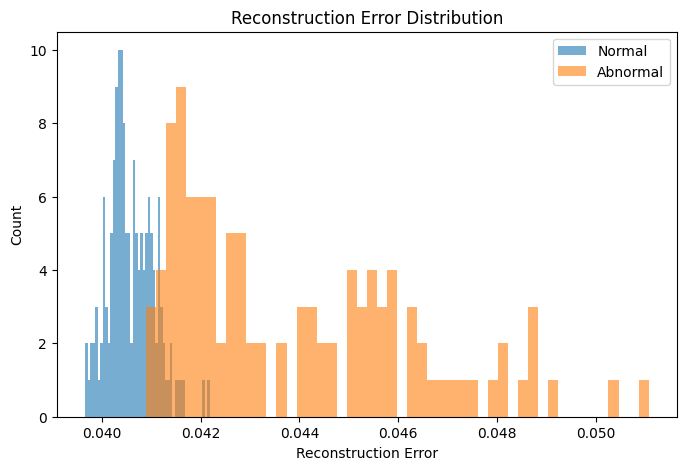

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()


In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)

Threshold: 0.04199199


In [ ]:
model.save("model_id_02.keras")
np.save("train_min_id_02.npy", train_min)
np.save("train_max_id_02.npy", train_max)
# np.save("threshold_id_02.npy", threshold)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_02.keras")

train_min = np.load("train_min_id_02.npy").item()
train_max = np.load("train_max_id_02.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_02_features.csv",index=False)

print("id_02_features.csv created")

id_02_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_02_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_02_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

RF CV AUC: 0.9964 ± 0.0022


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

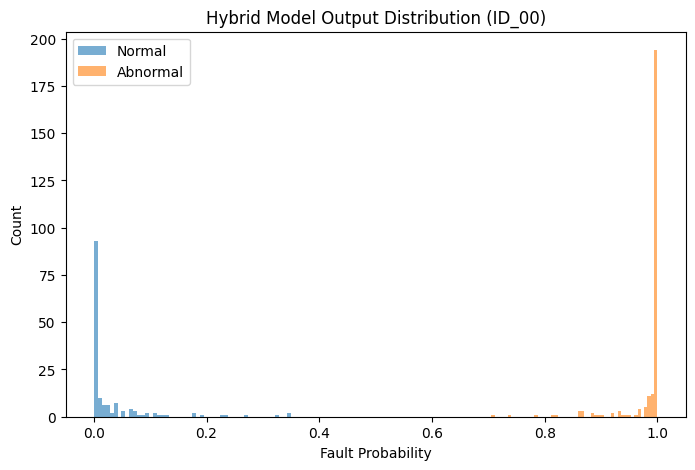

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
# Use the X data that the rf_model was trained on, along with its labels y
prob = rf_model.predict_proba(X)[:,1]

# split by label
normal_prob = prob[y == 0]
abnormal_prob = prob[y == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_00)")

plt.legend()
plt.show()

        HELD-OUT TEST SET METRICS
  AUC Score       : 0.9901
  pAUC (FPR≤0.1)  : 0.9485
  pAUC Normalized : 9.4846
  Accuracy        : 0.9502
  Precision       : 0.9204
  Recall          : 0.9630
  F1 Score        : 0.9412

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.94      0.96       153
    Abnormal       0.92      0.96      0.94       108

    accuracy                           0.95       261
   macro avg       0.95      0.95      0.95       261
weighted avg       0.95      0.95      0.95       261



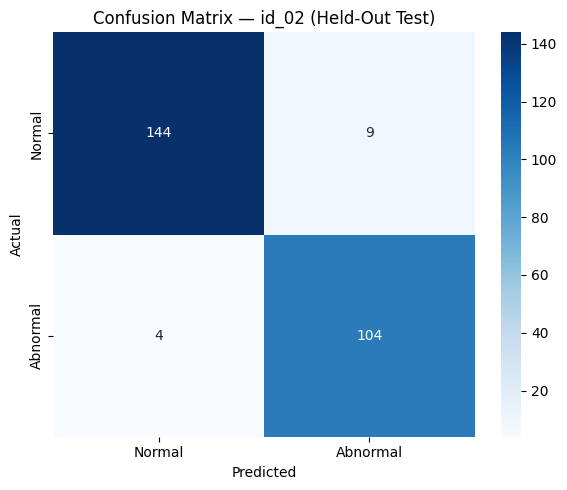

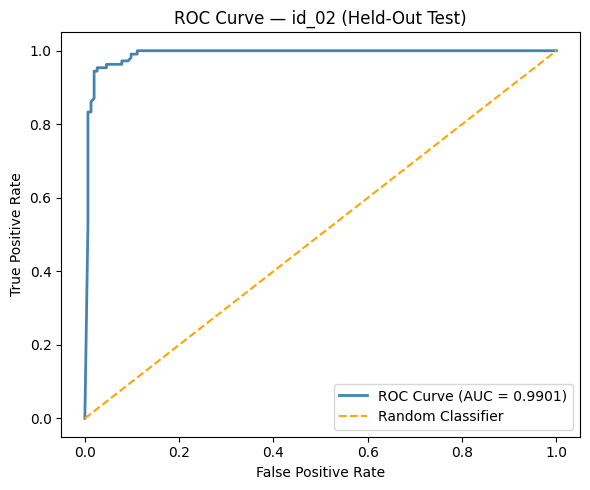


RF Cross-Validation AUC (training set): 0.9964 ± 0.0022
RF Held-Out Test AUC:                    0.9901


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────
# STEP 1: Extract features from HELD-OUT test set
# ─────────────────────────────────────────

test_results = []

for file in normal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["normal", error, centroid, bandwidth, energy, dom])

for file in abnormal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["abnormal", error, centroid, bandwidth, energy, dom])

df_test = pd.DataFrame(
    test_results,
    columns=["condition", "reconstruction_error",
             "centroid", "bandwidth", "energy", "dominant_freq"]
)

# ─────────────────────────────────────────
# STEP 2: Prepare test features and labels
# ─────────────────────────────────────────

X_final = df_test[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]
y_final = df_test["condition"].map({"normal": 0, "abnormal": 1})

prob  = rf_model.predict_proba(X_final)[:, 1]
y_pred = rf_model.predict(X_final)

# ─────────────────────────────────────────
# STEP 3: Print all metrics including pAUC
# ─────────────────────────────────────────

auc = roc_auc_score(y_final, prob)

# pAUC restricted to FPR <= 0.1 (official MIMII metric)
pauc = roc_auc_score(y_final, prob, max_fpr=0.1)

# pAUC normalized to [0,1] range by dividing by the FPR limit
pauc_normalized = pauc / 0.1

print("=" * 45)
print("        HELD-OUT TEST SET METRICS")
print("=" * 45)
print(f"  AUC Score       : {auc:.4f}")
print(f"  pAUC (FPR≤0.1)  : {pauc:.4f}")
print(f"  pAUC Normalized : {pauc_normalized:.4f}")
print(f"  Accuracy        : {accuracy_score(y_final, y_pred):.4f}")
print(f"  Precision       : {precision_score(y_final, y_pred):.4f}")
print(f"  Recall          : {recall_score(y_final, y_pred):.4f}")
print(f"  F1 Score        : {f1_score(y_final, y_pred):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_final, y_pred, target_names=["Normal", "Abnormal"]))

# ─────────────────────────────────────────
# STEP 4: Confusion Matrix
# ─────────────────────────────────────────

cm = confusion_matrix(y_final, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — id_02 (Held-Out Test)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 5: ROC Curve
# ─────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_final, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — id_02 (Held-Out Test)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 6: CV AUC on RF training set
# ─────────────────────────────────────────

print(f"\nRF Cross-Validation AUC (training set): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"RF Held-Out Test AUC:                    {auc:.4f}")

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Add this line to allow unsupported TF ops
]

tflite_model = converter.convert()

with open("model_edge_ready.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Fully edge-ready TFLite model saved")

Saved artifact at '/tmp/tmplepu4nks'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  138349286592528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286589840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286594256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286594832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346192721040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286591376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286593488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286592144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286593680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138349286593104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138

In [ ]:
interpreter = tf.lite.Interpreter(model_path="model_edge_ready.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Input dtype:", input_details[0]['dtype'])
print("Output shape:", output_details[0]['shape'])

# Test inference
import numpy as np
test_input = np.random.rand(1, 128, 128, 1).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print("Output shape:", output.shape)

Input shape: [  1 128 128   1]
Input dtype: <class 'numpy.float32'>
Output shape: [  1 128 128   1]
Output shape: (1, 128, 128, 1)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
def tflite_predict(data):

    preds = []

    for i in range(len(data)):

        sample = data[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], sample)

        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        preds.append(output[0])

    return np.array(preds)

In [ ]:
recon_normal_tflite = tflite_predict(X_test_normal)
recon_abnormal_tflite = tflite_predict(X_test_abnormal)

In [ ]:
error_normal_tflite = np.mean(
    np.abs(X_test_normal - recon_normal_tflite),
    axis=(1,2,3)
)

error_abnormal_tflite = np.mean(
    np.abs(X_test_abnormal - recon_abnormal_tflite),
    axis=(1,2,3)
)

In [ ]:
from sklearn.metrics import roc_auc_score

y_true = np.concatenate([
    np.zeros(len(error_normal_tflite)),
    np.ones(len(error_abnormal_tflite))
])

y_scores = np.concatenate([
    error_normal_tflite,
    error_abnormal_tflite
])

auc_tflite = roc_auc_score(y_true, y_scores)

print("TFLite AUC:", auc_tflite)

TFLite AUC: 0.9814209634471072


#ID_04

In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_04"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1033
Abnormal files: 348


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel

In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

Normal AE train: 723
Normal RF: 155
Normal test: 155
Abnormal RF: 243
Abnormal test: 105


In [ ]:
X_train = []

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (723, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

#Bottleneck
x= layers.Conv2D(32,3,activation='relu',padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(32,3,activation='relu',padding='same', strides=2)(x)

x = layers.Conv2DTranspose(64,3,activation='relu',padding='same', strides=2)(x)

x = layers.Conv2DTranspose(32,3,activation='relu',padding='same', strides=2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - loss: 0.0248 - val_loss: 0.0163
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0150 - val_loss: 0.0139
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0133 - val_loss: 0.0125
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0121 - val_loss: 0.0114
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0111 - val_loss: 0.0105
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0095 - val_loss: 0.0091
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0083 - val_loss: 0.0080
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0078 - val_loss: 0.0074
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0073 - val_loss: 0.0070
Epoch 12/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data


X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)

In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 581ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 0.7198771121351767


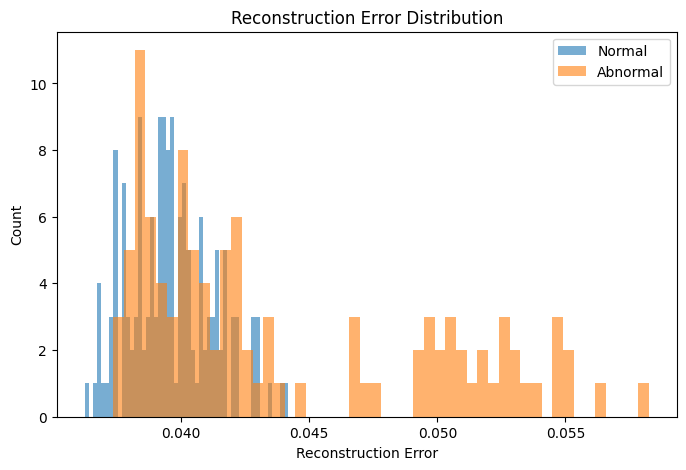

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)

Threshold: 0.044565562


In [ ]:
model.save("model_id_04.keras")
np.save("train_min_id_04.npy", train_min)
np.save("train_max_id_04.npy", train_max)
# np.save("threshold_id_04.npy", threshold)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_04.keras")

train_min = np.load("train_min_id_04.npy").item()
train_max = np.load("train_max_id_04.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_04_features.csv",index=False)

print("id_04_features.csv created")

id_04_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_04_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_04_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

RF CV AUC: 0.9463 ± 0.0086


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

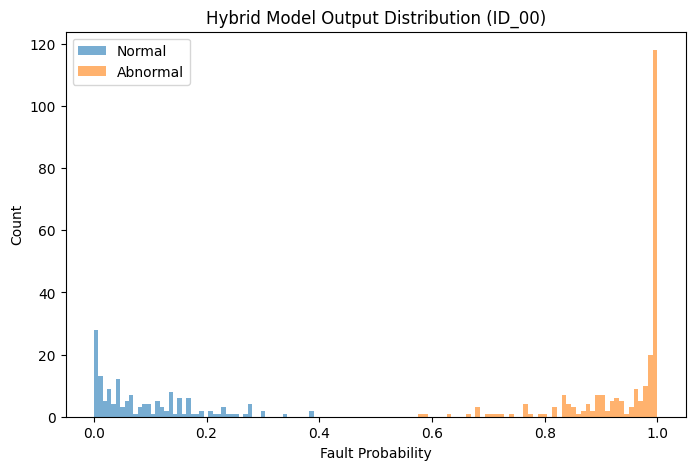

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
# Use the X data that the rf_model was trained on, along with its labels y
prob = rf_model.predict_proba(X)[:,1]

# split by label
normal_prob = prob[y == 0]
abnormal_prob = prob[y == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_00)")

plt.legend()
plt.show()

        HELD-OUT TEST SET METRICS
  AUC Score       : 0.9701
  pAUC (FPR≤0.1)  : 0.9193
  pAUC Normalized : 9.1931
  Accuracy        : 0.8923
  Precision       : 0.8182
  Recall          : 0.9429
  F1 Score        : 0.8761

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.86      0.90       155
    Abnormal       0.82      0.94      0.88       105

    accuracy                           0.89       260
   macro avg       0.89      0.90      0.89       260
weighted avg       0.90      0.89      0.89       260



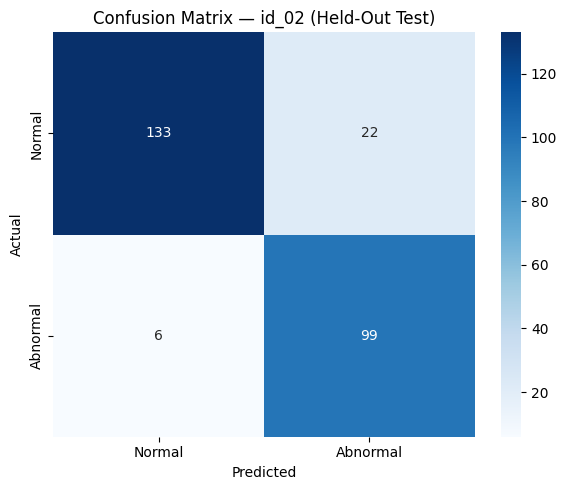

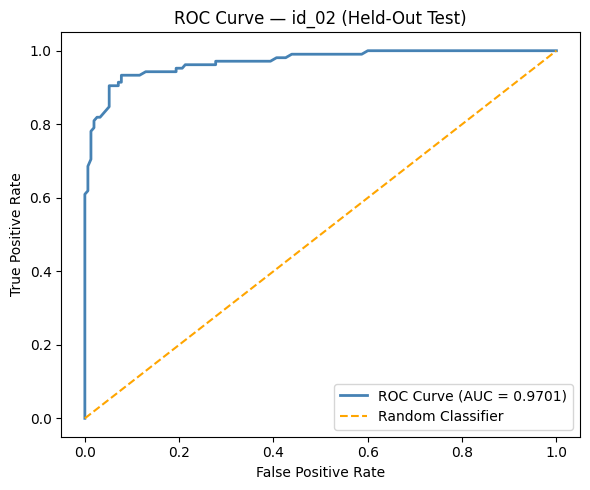


RF Cross-Validation AUC (training set): 0.9463 ± 0.0086
RF Held-Out Test AUC:                    0.9701


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────
# STEP 1: Extract features from HELD-OUT test set
# ─────────────────────────────────────────

test_results = []

for file in normal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["normal", error, centroid, bandwidth, energy, dom])

for file in abnormal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["abnormal", error, centroid, bandwidth, energy, dom])

df_test = pd.DataFrame(
    test_results,
    columns=["condition", "reconstruction_error",
             "centroid", "bandwidth", "energy", "dominant_freq"]
)

# ─────────────────────────────────────────
# STEP 2: Prepare test features and labels
# ─────────────────────────────────────────

X_final = df_test[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]
y_final = df_test["condition"].map({"normal": 0, "abnormal": 1})

prob  = rf_model.predict_proba(X_final)[:, 1]
y_pred = rf_model.predict(X_final)

# ─────────────────────────────────────────
# STEP 3: Print all metrics including pAUC
# ─────────────────────────────────────────

auc = roc_auc_score(y_final, prob)

# pAUC restricted to FPR <= 0.1 (official MIMII metric)
pauc = roc_auc_score(y_final, prob, max_fpr=0.1)

# pAUC normalized to [0,1] range by dividing by the FPR limit
pauc_normalized = pauc / 0.1

print("=" * 45)
print("        HELD-OUT TEST SET METRICS")
print("=" * 45)
print(f"  AUC Score       : {auc:.4f}")
print(f"  pAUC (FPR≤0.1)  : {pauc:.4f}")
print(f"  pAUC Normalized : {pauc_normalized:.4f}")
print(f"  Accuracy        : {accuracy_score(y_final, y_pred):.4f}")
print(f"  Precision       : {precision_score(y_final, y_pred):.4f}")
print(f"  Recall          : {recall_score(y_final, y_pred):.4f}")
print(f"  F1 Score        : {f1_score(y_final, y_pred):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_final, y_pred, target_names=["Normal", "Abnormal"]))

# ─────────────────────────────────────────
# STEP 4: Confusion Matrix
# ─────────────────────────────────────────

cm = confusion_matrix(y_final, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — id_02 (Held-Out Test)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 5: ROC Curve
# ─────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_final, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — id_02 (Held-Out Test)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 6: CV AUC on RF training set
# ─────────────────────────────────────────

print(f"\nRF Cross-Validation AUC (training set): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"RF Held-Out Test AUC:                    {auc:.4f}")

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Add this line to allow unsupported TF ops
]

tflite_model = converter.convert()

with open("model_edge_ready.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Fully edge-ready TFLite model saved")

Saved artifact at '/tmp/tmpzx690asy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  133667066195472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066183760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066189136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066195088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066194320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066192784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066198736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066197968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066186256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133667066199696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13366

In [ ]:
interpreter = tf.lite.Interpreter(model_path="model_edge_ready.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Input dtype:", input_details[0]['dtype'])
print("Output shape:", output_details[0]['shape'])

# Test inference
import numpy as np
test_input = np.random.rand(1, 128, 128, 1).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print("Output shape:", output.shape)

Input shape: [  1 128 128   1]
Input dtype: <class 'numpy.float32'>
Output shape: [  1 128 128   1]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Output shape: (1, 128, 128, 1)


In [ ]:
def tflite_predict(data):

    preds = []

    for i in range(len(data)):

        sample = data[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], sample)

        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        preds.append(output[0])

    return np.array(preds)

In [ ]:
recon_normal_tflite = tflite_predict(X_test_normal)
recon_abnormal_tflite = tflite_predict(X_test_abnormal)

In [ ]:
error_normal_tflite = np.mean(
    np.abs(X_test_normal - recon_normal_tflite),
    axis=(1,2,3)
)

error_abnormal_tflite = np.mean(
    np.abs(X_test_abnormal - recon_abnormal_tflite),
    axis=(1,2,3)
)

In [ ]:
from sklearn.metrics import roc_auc_score

y_true = np.concatenate([
    np.zeros(len(error_normal_tflite)),
    np.ones(len(error_abnormal_tflite))
])

y_scores = np.concatenate([
    error_normal_tflite,
    error_abnormal_tflite
])

auc_tflite = roc_auc_score(y_true, y_scores)

print("TFLite AUC:", auc_tflite)

TFLite AUC: 0.7170506912442397


# ID_06

In [ ]:
import os
import glob

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"
target_id = "id_06"   # change if needed

id_path = os.path.join(base_path, target_id)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))

Normal files: 1015
Abnormal files: 361


In [ ]:
import librosa
import numpy as np

def wav_to_mel(file_path, sr=16000, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=1024,
        hop_length=512,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def fix_length(mel, target_frames=128):
    if mel.shape[1] < target_frames:
        pad_width = target_frames - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :target_frames]
    return mel

In [ ]:
from sklearn.model_selection import train_test_split

# ---------- NORMAL SPLIT ----------
# 15% final test
normal_train_val, normal_test = train_test_split(
    normal_files,
    test_size=0.15,
    random_state=42
)

# From remaining 85%, take ~15% RF set
normal_train, normal_rf = train_test_split(
    normal_train_val,
    test_size=0.176,  # 0.176 × 0.85 ≈ 0.15 total
    random_state=42
)

# ---------- ABNORMAL SPLIT ----------
abnormal_rf, abnormal_test = train_test_split(
    abnormal_files,
    test_size=0.30,
    random_state=42
)

print("Normal AE train:", len(normal_train))
print("Normal RF:", len(normal_rf))
print("Normal test:", len(normal_test))

print("Abnormal RF:", len(abnormal_rf))
print("Abnormal test:", len(abnormal_test))

Normal AE train: 710
Normal RF: 152
Normal test: 153
Abnormal RF: 252
Abnormal test: 109


In [ ]:
X_train = []

from sklearn.model_selection import train_test_split

for file in normal_train:
    mel = wav_to_mel(file)
    mel = fix_length(mel)
    X_train.append(mel)

X_train = np.array(X_train)

# Save train normalization values
train_min = X_train.min()
train_max = X_train.max()

X_train = (X_train - train_min) / (train_max - train_min)

X_train = X_train[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (710, 128, 128, 1)


In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

#Bottleneck
x= layers.Conv2D(32,3,activation='relu',padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(32,3,activation='relu',padding='same', strides=2)(x)

x = layers.Conv2DTranspose(64,3,activation='relu',padding='same', strides=2)(x)

x = layers.Conv2DTranspose(32,3,activation='relu',padding='same', strides=2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras import layers, models

input_shape = (128,128,1)
inputs = layers.Input(shape=input_shape)

# Encoder (3 pools)
x = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
encoded = layers.MaxPooling2D(2,padding='same')(x)

# Decoder (3 upsamples)
x = layers.Conv2D(64,3,activation='relu',padding='same')(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32,3,activation='relu',padding='same')(x)
x = layers.UpSampling2D(2)(x)

outputs = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0214 - val_loss: 0.0120
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0067 - val_loss: 0.0044
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0

In [ ]:
def prepare_dataset(file_list):
    data = []
    for file in file_list:
        mel = wav_to_mel(file)
        mel = fix_length(mel)
        data.append(mel)
    data = np.array(data)

    # Use TRAIN normalization only
    data = (data - train_min) / (train_max - train_min)

    data = data[..., np.newaxis]
    return data


X_test_normal = prepare_dataset(normal_test)
X_test_abnormal = prepare_dataset(abnormal_test)

In [ ]:
import numpy as np

recon_normal = model.predict(X_test_normal)
error_normal = np.mean(np.abs(X_test_normal - recon_normal), axis=(1,2,3))



recon_abnormal = model.predict(X_test_abnormal)
error_abnormal = np.mean(np.abs(X_test_abnormal - recon_abnormal), axis=(1,2,3))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 541ms/step


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.concatenate([
    np.zeros(len(error_normal)),
    np.ones(len(error_abnormal))
])

y_scores = np.concatenate([
    error_normal,
    error_abnormal
])

auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 0.9743359117347244


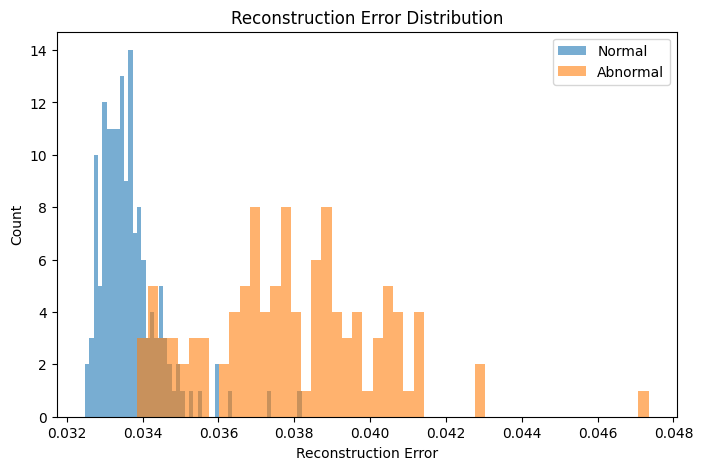

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(error_normal, bins=50, alpha=0.6, label='Normal')
plt.hist(error_abnormal, bins=50, alpha=0.6, label='Abnormal')

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

In [ ]:
threshold = np.mean(error_normal) + 3 * np.std(error_normal)
print("Threshold:", threshold)

Threshold: 0.035349663


In [ ]:
model.save("model_id_06.keras")
np.save("train_min_id_06.npy", train_min)
np.save("train_max_id_06.npy", train_max)
# np.save("threshold_id_06.npy", threshold)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from tensorflow.keras.models import load_model

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

model = load_model("model_id_06.keras")

train_min = np.load("train_min_id_06.npy").item()
train_max = np.load("train_max_id_06.npy").item()

results = []

# -----------------------------
# Feature Extraction
# -----------------------------

def extract_features(y,sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))
    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dom = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dom


def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel = librosa.power_to_db(mel,ref=np.max)

    if mel.shape[1] < IMG_WIDTH:
        mel = np.pad(mel,((0,0),(0,IMG_WIDTH-mel.shape[1])),mode='constant')
    else:
        mel = mel[:,:IMG_WIDTH]

    return mel


# -----------------------------
# PROCESS TEST NORMAL FILES
# -----------------------------

for file in normal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "normal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# PROCESS ABNORMAL FILES
# -----------------------------

for file in abnormal_rf:

    y,sr = librosa.load(file,sr=SR)

    centroid,bandwidth,energy,dom = extract_features(y,sr)

    mel = extract_mel(y)

    mel = (mel-train_min)/(train_max-train_min)

    mel = mel[...,np.newaxis]
    mel = np.expand_dims(mel,0)

    recon = model.predict(mel,verbose=0)

    error = np.mean(np.abs(mel-recon))

    results.append([
        "abnormal",error,centroid,bandwidth,energy,dom
    ])


# -----------------------------
# SAVE DATASET
# -----------------------------

df = pd.DataFrame(
    results,
    columns=[
        "condition",
        "reconstruction_error",
        "centroid",
        "bandwidth",
        "energy",
        "dominant_freq"
    ]
)

df.to_csv("id_06_features.csv",index=False)

print("id_06_features.csv created")

id_06_features.csv created


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import joblib

data = pd.read_csv("id_06_features.csv")

X = data[
    ["reconstruction_error",
     "centroid",
     "bandwidth",
     "dominant_freq"]
]

y = data["condition"].map({"normal":0,"abnormal":1})

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # handles normal/abnormal imbalance
    random_state=42           # reproducibility for your report
)

rf_model.fit(X, y)

# SAVE MODEL
joblib.dump(rf_model, "id_06_fault_model.pkl")

print("Random Forest model saved")

Random Forest model saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"RF CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Then train final model on full RF set for deployment
rf_model.fit(X, y)

RF CV AUC: 0.9975 ± 0.0046


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
import matplotlib.pyplot as plt

# predicted probability of abnormal
prob = rf_model.predict_proba(X_test)[:,1]

# split by label
normal_prob = prob[y_test == 0]
abnormal_prob = prob[y_test == 1]

plt.figure(figsize=(8,5))

plt.hist(normal_prob, bins=50, alpha=0.6, label="Normal")
plt.hist(abnormal_prob, bins=50, alpha=0.6, label="Abnormal")

plt.xlabel("Fault Probability")
plt.ylabel("Count")
plt.title("Hybrid Model Output Distribution (ID_06)")

plt.legend()
plt.show()

NameError: name 'X_test' is not defined

        HELD-OUT TEST SET METRICS
  AUC Score       : 0.9890
  pAUC (FPR≤0.1)  : 0.9419
  pAUC Normalized : 9.4193
  Accuracy        : 0.9733
  Precision       : 0.9474
  Recall          : 0.9908
  F1 Score        : 0.9686

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98       153
    Abnormal       0.95      0.99      0.97       109

    accuracy                           0.97       262
   macro avg       0.97      0.98      0.97       262
weighted avg       0.97      0.97      0.97       262



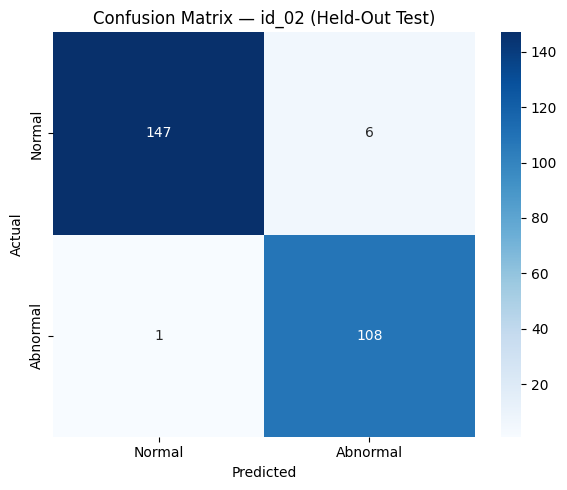

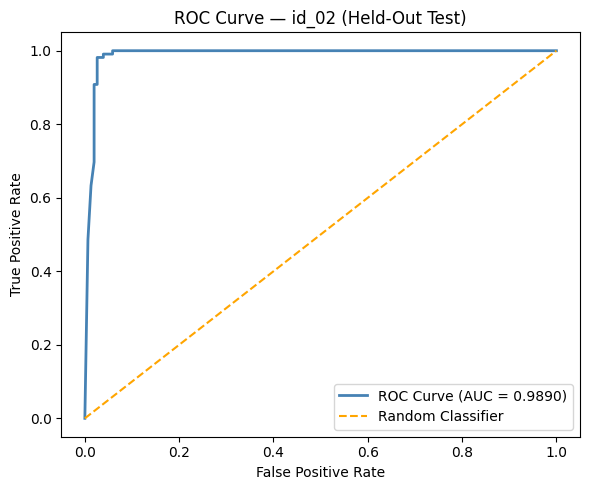


RF Cross-Validation AUC (training set): 0.9975 ± 0.0046
RF Held-Out Test AUC:                    0.9890


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ─────────────────────────────────────────
# STEP 1: Extract features from HELD-OUT test set
# ─────────────────────────────────────────

test_results = []

for file in normal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["normal", error, centroid, bandwidth, energy, dom])

for file in abnormal_test:
    y, sr = librosa.load(file, sr=SR)
    centroid, bandwidth, energy, dom = extract_features(y, sr)
    mel = extract_mel(y)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, 0)
    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))
    test_results.append(["abnormal", error, centroid, bandwidth, energy, dom])

df_test = pd.DataFrame(
    test_results,
    columns=["condition", "reconstruction_error",
             "centroid", "bandwidth", "energy", "dominant_freq"]
)

# ─────────────────────────────────────────
# STEP 2: Prepare test features and labels
# ─────────────────────────────────────────

X_final = df_test[["reconstruction_error", "centroid", "bandwidth", "dominant_freq"]]
y_final = df_test["condition"].map({"normal": 0, "abnormal": 1})

prob  = rf_model.predict_proba(X_final)[:, 1]
y_pred = rf_model.predict(X_final)

# ─────────────────────────────────────────
# STEP 3: Print all metrics including pAUC
# ─────────────────────────────────────────

auc = roc_auc_score(y_final, prob)

# pAUC restricted to FPR <= 0.1 (official MIMII metric)
pauc = roc_auc_score(y_final, prob, max_fpr=0.1)

# pAUC normalized to [0,1] range by dividing by the FPR limit
pauc_normalized = pauc / 0.1

print("=" * 45)
print("        HELD-OUT TEST SET METRICS")
print("=" * 45)
print(f"  AUC Score       : {auc:.4f}")
print(f"  pAUC (FPR≤0.1)  : {pauc:.4f}")
print(f"  pAUC Normalized : {pauc_normalized:.4f}")
print(f"  Accuracy        : {accuracy_score(y_final, y_pred):.4f}")
print(f"  Precision       : {precision_score(y_final, y_pred):.4f}")
print(f"  Recall          : {recall_score(y_final, y_pred):.4f}")
print(f"  F1 Score        : {f1_score(y_final, y_pred):.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_final, y_pred, target_names=["Normal", "Abnormal"]))

# ─────────────────────────────────────────
# STEP 4: Confusion Matrix
# ─────────────────────────────────────────

cm = confusion_matrix(y_final, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — id_02 (Held-Out Test)")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 5: ROC Curve
# ─────────────────────────────────────────

fpr, tpr, _ = roc_curve(y_final, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — id_02 (Held-Out Test)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# STEP 6: CV AUC on RF training set
# ─────────────────────────────────────────

print(f"\nRF Cross-Validation AUC (training set): "
      f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"RF Held-Out Test AUC:                    {auc:.4f}")

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Add this line to allow unsupported TF ops
]

tflite_model = converter.convert()

with open("model_edge_ready.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Fully edge-ready TFLite model saved")

Saved artifact at '/tmp/tmp06vkxdis'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_8')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  138346150519696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150522960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150525840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150514704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150525456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150525648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150525072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150525264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150524688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346150524880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138

In [ ]:
interpreter = tf.lite.Interpreter(model_path="model_edge_ready.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Input dtype:", input_details[0]['dtype'])
print("Output shape:", output_details[0]['shape'])

# Test inference
import numpy as np
test_input = np.random.rand(1, 128, 128, 1).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print("Output shape:", output.shape)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input shape: [  1 128 128   1]
Input dtype: <class 'numpy.float32'>
Output shape: [  1 128 128   1]
Output shape: (1, 128, 128, 1)


In [ ]:
def tflite_predict(data):

    preds = []

    for i in range(len(data)):

        sample = data[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], sample)

        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        preds.append(output[0])

    return np.array(preds)

In [ ]:
recon_normal_tflite = tflite_predict(X_test_normal)
recon_abnormal_tflite = tflite_predict(X_test_abnormal)

In [ ]:
error_normal_tflite = np.mean(
    np.abs(X_test_normal - recon_normal_tflite),
    axis=(1,2,3)
)

error_abnormal_tflite = np.mean(
    np.abs(X_test_abnormal - recon_abnormal_tflite),
    axis=(1,2,3)
)

In [ ]:
from sklearn.metrics import roc_auc_score

y_true = np.concatenate([
    np.zeros(len(error_normal_tflite)),
    np.ones(len(error_abnormal_tflite))
])

y_scores = np.concatenate([
    error_normal_tflite,
    error_abnormal_tflite
])

auc_tflite = roc_auc_score(y_true, y_scores)

print("TFLite AUC:", auc_tflite)

TFLite AUC: 0.2369730766924507


## TFLITE SECTION

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/model_id_06(tf).keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Force strict TFLite ops only
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter.optimizations = [tf.lite.Optimize.DEFAULT]

try:
    tflite_model = converter.convert()
    print("✅ Conversion SUCCESS (pure TFLite)")

    with open("test_model.tflite", "wb") as f:
        f.write(tflite_model)

except Exception as e:
    print("❌ Conversion FAILED")
    print(e)

Saved artifact at '/tmp/tmpdq8jdlh9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  132304916870544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916868816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916864976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916868240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916858064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916865168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916871504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916863440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916872656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132304916869392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13230

In [ ]:
for layer in model.layers:
    print(layer.name, "->", layer.__class__.__name__)

input_layer_3 -> InputLayer
conv2d_21 -> Conv2D
max_pooling2d_9 -> MaxPooling2D
conv2d_22 -> Conv2D
max_pooling2d_10 -> MaxPooling2D
conv2d_23 -> Conv2D
max_pooling2d_11 -> MaxPooling2D
conv2d_24 -> Conv2D
up_sampling2d_9 -> UpSampling2D
conv2d_25 -> Conv2D
up_sampling2d_10 -> UpSampling2D
conv2d_26 -> Conv2D
up_sampling2d_11 -> UpSampling2D
conv2d_27 -> Conv2D


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/model_id_00.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]  # ✅ No SELECT_TF_OPS

tflite_model = converter.convert()

with open("model_edge_ready.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Fully edge-ready TFLite model saved")

Saved artifact at '/tmp/tmpj0j1f4w9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  138348595062416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681150416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681149072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681150032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681141776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681148880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681148688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681145616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681146768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138346681148496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(fused["Conv2D:", "functional_3_1/conv2d_26_1/convolution@__inference_function_44570"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_44637"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.Conv2D' op is neither a custom op nor a flex op
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_44637"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(fused["Conv2D:", "functional_3_1/conv2d_26_1/convolution@__inference_function_44570"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_44637"] at fused["StatefulPartitionedCall:", "StatefulPartitionedC

In [ ]:
interpreter = tf.lite.Interpreter(model_path="model_edge_ready.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape:", input_details[0]['shape'])
print("Input dtype:", input_details[0]['dtype'])
print("Output shape:", output_details[0]['shape'])

# Test inference
import numpy as np
test_input = np.random.rand(1, 128, 128, 1).astype(np.float32)
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print("Output shape:", output.shape)

Input shape: [  1 128 128   1]
Input dtype: <class 'numpy.float32'>
Output shape: [  1 128 128   1]
Output shape: (1, 128, 128, 1)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
def tflite_predict(data):

    preds = []

    for i in range(len(data)):

        sample = data[i:i+1].astype(np.float32)

        interpreter.set_tensor(input_details[0]['index'], sample)

        interpreter.invoke()

        output = interpreter.get_tensor(output_details[0]['index'])

        preds.append(output[0])

    return np.array(preds)

In [ ]:
recon_normal_tflite = tflite_predict(X_test_normal)
recon_abnormal_tflite = tflite_predict(X_test_abnormal)

In [ ]:
error_normal_tflite = np.mean(
    np.abs(X_test_normal - recon_normal_tflite),
    axis=(1,2,3)
)

error_abnormal_tflite = np.mean(
    np.abs(X_test_abnormal - recon_abnormal_tflite),
    axis=(1,2,3)
)

In [ ]:
from sklearn.metrics import roc_auc_score

y_true = np.concatenate([
    np.zeros(len(error_normal_tflite)),
    np.ones(len(error_abnormal_tflite))
])

y_scores = np.concatenate([
    error_normal_tflite,
    error_abnormal_tflite
])

auc_tflite = roc_auc_score(y_true, y_scores)

print("TFLite AUC:", auc_tflite)

TFLite AUC: 0.9712178449361397


In [ ]:
import tensorflow as tf

models = [
"model_id_00.keras",
"model_id_02.keras",
"model_id_04.keras",
"model_id_06.keras"
]

for model_path in models:

    print("Converting:", model_path)

    model = tf.keras.models.load_model(model_path)

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ] # Add this line to allow unsupported TF ops

    tflite_model = converter.convert()

    output_name = model_path.replace(".keras", ".tflite")

    with open(output_name, "wb") as f:
        f.write(tflite_model)

print("All models converted successfully")

Converting: model_id_00.keras
Saved artifact at '/tmp/tmpryolpk37'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None)
Captures:
  132705414028304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414029456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414028688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414030032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414028112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414027344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414030608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414029264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414026960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132705414030224: TensorSpec(shape=(), dtype=t

## EVALUATION

In [ ]:
# ==========================================
# FULL ID EVALUATION (Counts + Metrics)
# ==========================================

import numpy as np
import glob
import os
import librosa
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# Configuration
# -----------------------------

BASE_PATH = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128


# -----------------------------
# Choose ID
# -----------------------------

id_name = "id_00"   # CHANGE HERE

print(f"\nEvaluating entire dataset for {id_name}")


# -----------------------------
# Load model + params
# -----------------------------

model = load_model(f"model_{id_name}.keras")
train_min = np.load(f"train_min_{id_name}.npy").item()
train_max = np.load(f"train_max_{id_name}.npy").item()
threshold = np.load(f"threshold_{id_name}.npy").item()


# -----------------------------
# Mel function
# -----------------------------

def extract_mel(file_path):
    y, sr = librosa.load(file_path, sr=SR)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < IMG_WIDTH:
        pad = IMG_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
    else:
        mel_db = mel_db[:, :IMG_WIDTH]

    return mel_db


# -----------------------------
# Load all files
# -----------------------------

id_path = os.path.join(BASE_PATH, id_name)

normal_files = glob.glob(os.path.join(id_path, "normal/*.wav"))
abnormal_files = glob.glob(os.path.join(id_path, "abnormal/*.wav"))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))


# -----------------------------
# Evaluate
# -----------------------------

y_true = []
y_pred = []

def predict_file(file_path):
    mel = extract_mel(file_path)
    mel = (mel - train_min) / (train_max - train_min)
    mel = mel[..., np.newaxis]
    mel = np.expand_dims(mel, axis=0)

    recon = model.predict(mel, verbose=0)
    error = np.mean(np.abs(mel - recon))

    return 1 if error > threshold else 0


# Evaluate normal files
for file in normal_files:
    y_true.append(0)
    y_pred.append(predict_file(file))

# Evaluate abnormal files
for file in abnormal_files:
    y_true.append(1)
    y_pred.append(predict_file(file))


# -----------------------------
# Results
# -----------------------------

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Normal (TN):", tn)
print("False Alarm (FP):", fp)
print("Missed Fault (FN):", fn)
print("Correct Abnormal (TP):", tp)

print("\nTotal Abnormal Detected:", tp, "out of", len(abnormal_files))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


Evaluating entire dataset for id_00
Normal files: 1011
Abnormal files: 407

Confusion Matrix:
[[892 119]
 [121 286]]

True Normal (TN): 892
False Alarm (FP): 119
Missed Fault (FN): 121
Correct Abnormal (TP): 286

Total Abnormal Detected: 286 out of 407

Classification Report:
              precision    recall  f1-score   support

           0     0.8806    0.8823    0.8814      1011
           1     0.7062    0.7027    0.7044       407

    accuracy                         0.8307      1418
   macro avg     0.7934    0.7925    0.7929      1418
weighted avg     0.8305    0.8307    0.8306      1418



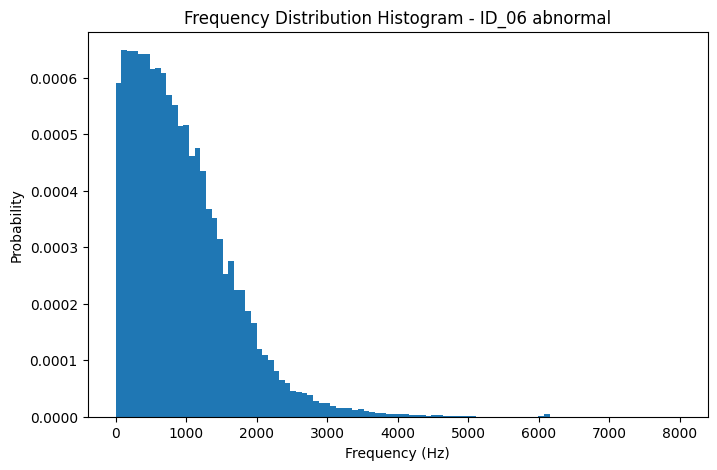

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

# path to one ID folder (example)
folder_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_00/abnormal"

all_freqs = []

for file in os.listdir(folder_path):
    if file.endswith(".wav"):
        filepath = os.path.join(folder_path, file)

        # load audio
        y, sr = librosa.load(filepath, sr=None)

        # FFT
        fft = np.fft.rfft(y)
        magnitude = np.abs(fft)

        # corresponding frequencies
        freqs = np.fft.rfftfreq(len(y), d=1/sr)

        # keep frequencies with significant energy
        mask = magnitude > np.mean(magnitude)
        dominant_freqs = freqs[mask]

        all_freqs.extend(dominant_freqs)

# convert to numpy
all_freqs = np.array(all_freqs)

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(all_freqs, bins=100, density=True)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Probability")
plt.title("Frequency Distribution Histogram - ID_06 abnormal")
plt.show()

In [ ]:
import os
import numpy as np
import librosa

folder = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_00/abnormal"

dominant_freqs = []

for file in os.listdir(folder):

    y, sr = librosa.load(os.path.join(folder,file), sr=None)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y),1/sr)

    mask = (freqs>=1000) & (freqs<=3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dominant = freqs[np.argmax(mag)]

    dominant_freqs.append(dominant)

print("Mean Dominant Frequency:",np.mean(dominant_freqs))
print("Std:",np.std(dominant_freqs))

Mean Dominant Frequency: 1263.8120393120394
Std: 224.78855142688644


In [ ]:
import os
import numpy as np
import librosa
import pandas as pd

folder = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_06/normal"

centroids = []
bandwidths = []
energies = []

for file in os.listdir(folder):

    if file.endswith(".wav"):
        path = os.path.join(folder, file)

        y, sr = librosa.load(path, sr=None)

        # Spectral Centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        centroids.append(np.mean(centroid))

        # Spectral Bandwidth
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        bandwidths.append(np.mean(bandwidth))

        # Energy
        energy = np.sum(y**2)
        energies.append(energy)

print("Spectral Centroid Mean:", np.mean(centroids))
print("Bandwidth Mean:", np.mean(bandwidths))
print("Energy Mean:", np.mean(energies))

Spectral Centroid Mean: 1512.705732350568
Bandwidth Mean: 1628.9956987805504
Energy Mean: 5.8689423


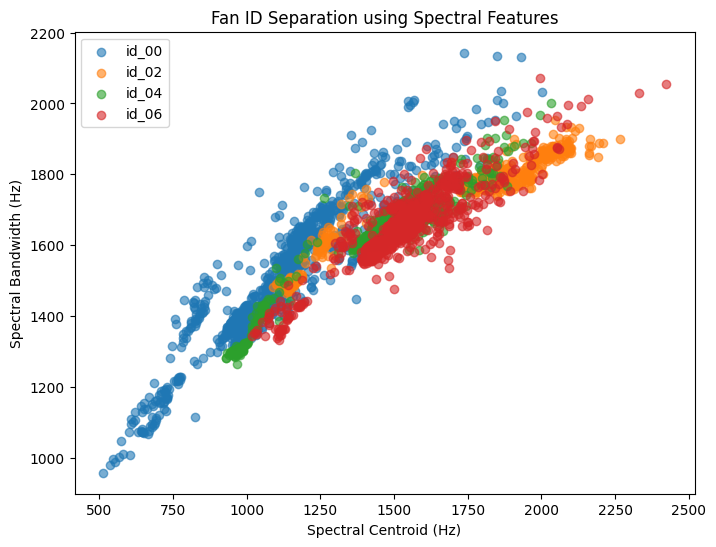

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load your feature dataset
data = pd.read_csv("/content/fan_features.csv")

plt.figure(figsize=(8,6))

ids = data["id"].unique()

for fan_id in ids:

    subset = data[data["id"] == fan_id]

    plt.scatter(
        subset["centroid"],
        subset["bandwidth"],
        label=fan_id,
        alpha=0.6
    )

plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("Spectral Bandwidth (Hz)")
plt.title("Fan ID Separation using Spectral Features")

plt.legend()
plt.show()

In [ ]:
import pandas as pd

data = pd.read_csv("fan_features.csv")

summary = data.groupby(["id","condition"]).mean()

print(summary)

                 dominant_freq     centroid    bandwidth    energy
id    condition                                                   
id_00 abnormal     1263.812039  1020.252667  1439.519510  7.218596
      normal       1245.214936  1139.902041  1517.076266  3.486827
id_02 abnormal     1348.109192  1685.406473  1727.947797  3.618840
      normal       1539.959646  1800.231421  1776.967636  4.088205
id_04 abnormal     1210.839368  1352.604750  1566.371486  5.587926
      normal       1228.137367  1485.869248  1653.645445  3.687557
id_06 abnormal     1230.614404  1468.457893  1633.867227  5.477146
      normal       1139.973990  1512.705732  1628.995699  5.868943


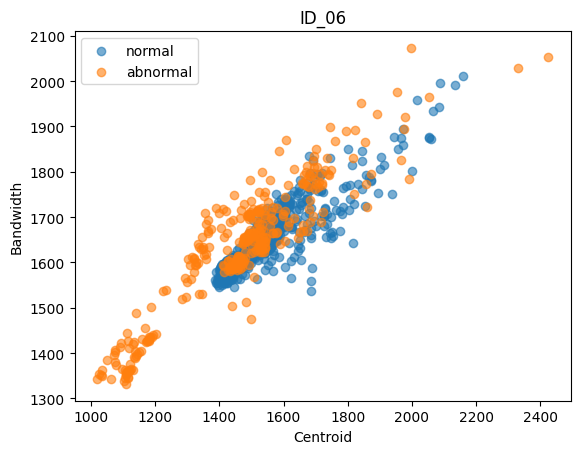

In [ ]:
import matplotlib.pyplot as plt

subset = data[data["id"]=="id_06"]

plt.scatter(
    subset[subset["condition"]=="normal"]["centroid"],
    subset[subset["condition"]=="normal"]["bandwidth"],
    label="normal",
    alpha=0.6
)

plt.scatter(
    subset[subset["condition"]=="abnormal"]["centroid"],
    subset[subset["condition"]=="abnormal"]["bandwidth"],
    label="abnormal",
    alpha=0.6
)

plt.legend()
plt.xlabel("Centroid")
plt.ylabel("Bandwidth")
plt.title("ID_06")
plt.show()

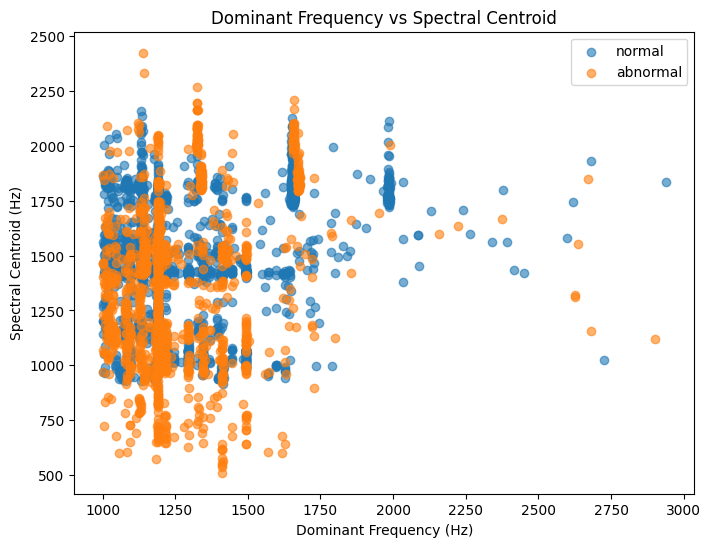

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("fan_features.csv")

plt.figure(figsize=(8,6))

normal = data[data["condition"]=="normal"]
abnormal = data[data["condition"]=="abnormal"]

plt.scatter(
    normal["dominant_freq"],
    normal["centroid"],
    alpha=0.6,
    label="normal"
)

plt.scatter(
    abnormal["dominant_freq"],
    abnormal["centroid"],
    alpha=0.6,
    label="abnormal"
)

plt.xlabel("Dominant Frequency (Hz)")
plt.ylabel("Spectral Centroid (Hz)")
plt.title("Dominant Frequency vs Spectral Centroid")

plt.legend()
plt.show()

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd

base_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan"

ids = ["id_00","id_02","id_04","id_06"]
conditions = ["normal","abnormal"]

data = []

for fan_id in ids:

    for condition in conditions:

        folder = os.path.join(base_path,fan_id,condition)

        for file in os.listdir(folder):

            if file.endswith(".wav"):

                path = os.path.join(folder,file)

                y, sr = librosa.load(path,sr=16000)

                # spectral centroid
                centroid = np.mean(librosa.feature.spectral_centroid(y=y,sr=sr))

                # bandwidth
                bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y,sr=sr))

                # energy
                energy = np.sum(y**2)

                # dominant frequency
                fft = np.fft.rfft(y)
                magnitude = np.abs(fft)
                freqs = np.fft.rfftfreq(len(y),1/sr)

                mask = (freqs>=1000) & (freqs<=3000)

                freqs = freqs[mask]
                magnitude = magnitude[mask]

                dominant = freqs[np.argmax(magnitude)]

                data.append([
                    fan_id,
                    condition,
                    dominant,
                    centroid,
                    bandwidth,
                    energy
                ])

df = pd.DataFrame(
    data,
    columns=[
        "id",
        "condition",
        "dominant_freq",
        "centroid",
        "bandwidth",
        "energy"
    ]
)

df.to_csv("fan_features.csv",index=False)

print("Feature dataset created")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# ==============================
# Load dataset
# ==============================

data = pd.read_csv("fan_features.csv")

# Spectral features
X = data[[
    "dominant_freq",
    "centroid",
    "bandwidth",
    "energy"
]]

# Target (fan ID)
y = data["id"]

# ==============================
# Train/Test split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==============================
# Train Random Forest
# ==============================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# Evaluate
# ==============================

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Fan ID Classifier Accuracy:", accuracy)

# ==============================
# Confusion Matrix (Figure 3)
# ==============================

labels = sorted(y.unique())

cm = confusion_matrix(y_test, pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix for Machine ID Classification")

plt.tight_layout()

plt.savefig("figure3_confusion_matrix.png", dpi=300)

plt.show()

# ==============================
# Save model
# ==============================

joblib.dump(model, "fan_id_classifier.pkl")

print("fan_id_classifier.pkl saved successfully")

### TESTING

In [ ]:
import numpy as np
import librosa
import joblib
from tensorflow.keras.models import load_model

# ==============================
# CONFIG
# ==============================

SR = 16000
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 512
IMG_WIDTH = 128

audio_path = "/content/drive/MyDrive/mimii_fan/6_dB_fan/fan/id_02/normal/00000001.wav"


# ==============================
# LOAD FAN ID CLASSIFIER
# ==============================

id_classifier = joblib.load("fan_id_classifier.pkl")


# ==============================
# FEATURE EXTRACTION FOR ID
# ==============================

def extract_features(y, sr):

    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))

    energy = np.sum(y**2)

    fft = np.fft.rfft(y)
    mag = np.abs(fft)
    freqs = np.fft.rfftfreq(len(y), 1/sr)

    mask = (freqs >= 1000) & (freqs <= 3000)

    freqs = freqs[mask]
    mag = mag[mask]

    dominant = freqs[np.argmax(mag)]

    return centroid, bandwidth, energy, dominant


# ==============================
# MEL SPECTROGRAM
# ==============================

def extract_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < IMG_WIDTH:
        pad = IMG_WIDTH - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
    else:
        mel_db = mel_db[:, :IMG_WIDTH]

    return mel_db


# ==============================
# LOAD AUDIO
# ==============================
y = y / np.max(np.abs(y) + 1e-8)
y, sr = librosa.load(audio_path, sr=SR)

centroid, bandwidth, energy, dom = extract_features(y, sr)

# features for ID classifier
id_features = np.array([[centroid, bandwidth, energy, dom]])

predicted_id = id_classifier.predict(id_features)[0]

print("\nDetected Fan ID:", predicted_id)


# ==============================
# LOAD CORRECT MODELS
# ==============================

autoencoder = load_model(f"model_{predicted_id}.keras")

fault_model = joblib.load(f"{predicted_id}_fault_model.pkl")


train_min = np.load(f"train_min_{predicted_id}.npy")
train_max = np.load(f"train_max_{predicted_id}.npy")


# ==============================
# AUTOENCODER INPUT
# ==============================

mel = extract_mel(y)

mel = (mel - train_min) / (train_max - train_min + 1e-8)

mel=np.array(mel)
mel = mel[..., np.newaxis]
mel = np.expand_dims(mel, axis=0)


# ==============================
# RECONSTRUCTION ERROR
# ==============================

recon = autoencoder.predict(mel)

reconstruction_error = np.mean(np.abs(mel - recon))

print("Reconstruction Error:", reconstruction_error)


# ==============================
# HYBRID FAULT CLASSIFIER
# ==============================

fault_features = np.array([[

    reconstruction_error,
    centroid,
    bandwidth,
    dom

]])

fault_features = scaler.transform(fault_features)

fault_prob = fault_model.predict_proba(fault_features)[0][1]

print("Fault Probability:", fault_prob)


# ==============================
# FINAL DECISION
# ==============================

if fault_prob > 0.5:

    print("\n⚠️ RESULT: FAN", predicted_id, "IS ABNORMAL")

else:

    print("\n✅ RESULT: FAN", predicted_id, "IS NORMAL")